# FIT5226 Project Stage 2: Multi-Agent Stochastic Games
**Student Name:** Juan Pulido
**Student ID:** 34169202

## Table of Contents
1. [AI Declaration](#AI-Declaration)
2. [Architecture and Mathematical Formulation](#Architecture-and-Mathematical-Formulation)
3. [Implementation](#Implementation)
4. [Task 1: Phase 1 Training](#Task-1-Training)
5. [Task 2: Phase 2 Training](#Task-2-Training)
6. [HD Experiment: Step Cost Magnitude](#HD-Experiment)
7. [Task 3: Game Theory and Replicator Dynamics](#Task-3-Game-Theory)
8. [Task 4: Theoretical Justification](#Task-4-Theory)
9. [Conclusion](#Conclusion)

## AI Declaration
Gemini CLI was used as an architectural co-pilot and auditor for this project. It assisted in refactoring the modular source code into this standalone notebook, identifying configuration bugs, and ensuring the mathematical formulations (EGT and Bellman updates) are correctly implemented. I, Juan Pulido, have reviewed every line of code and mathematical derivation, and I am prepared to defend the technical decisions and results in an interview.

## Architecture and Mathematical Formulation

### Multi-Agent Markov Decision Process (MMDP)
We model the coordination task as an MMDP where:
- **State Space $S$**: Defined by (row, col, has_sample, lake_flooded). Agents are independent learners and do not observe each other's locations, leading to a partially observable environment from an individual perspective.
- **Action Space $A$**: {North, South, East, West, Wait}.
- **Transition Dynamics $P$**: Deterministic movement within boundaries, coupled with a stochastic environment (lake state $L$).
- **Reward Function $R$**: As defined in the Phase 1 and Phase 2 specifications.

### Expected-Value Bellman Equation
To handle the stochasticity of the lake (which can flip between $t$ and $t+1$), we use an expected-value update rule:
$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \left((1-p)\max_{a'}Q(s'_{dry}, a') + p\max_{a'}Q(s'_{flooded}, a')\right) - Q(s,a)\right]$$
This update accounts for both possible future states of the lake, ensuring the agent's policy is robust to the environment's random flips. This is critical because a "dry" path at time $t$ might be "flooded" by the time the agent reaches it.

### Partial Observability and Independent Learning
While the global game is multi-agent, we employ **Independent Q-Learning**. In Phase 1, the environmental asymmetry (water hazard for Type A) serves as a correlating device, breaking the game's symmetry and leading to a unique Nash Equilibrium. In Phase 2, the game becomes symmetric (anti-coordination), and the lack of an external correlating mechanism makes convergence difficult for independent learners due to non-stationarity.

In [1]:
import numpy as np, random, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from collections import defaultdict
from dataclasses import dataclass, field, replace
from enum import IntEnum
from typing import Tuple, List, Dict, Any
from scipy.integrate import odeint
np.random.seed(42); random.seed(42)

In [2]:
@dataclass(frozen=True)
class AgentConfig:
    learning_rate_alpha: float
    discount_factor_gamma: float
    initial_epsilon: float
    epsilon_decay_rate: float
    minimum_epsilon: float
    action_size: int

@dataclass(frozen=True)
class EnvConfig:
    grid_rows: int; grid_cols: int; p_flood: float
    step_cost: float; wait_cost: float; pickup_reward: float; success_reward: float
    collision_penalty: float = 0.0; hazard_penalty: float = 0.0

@dataclass(frozen=True)
class ExperimentConfig:
    experiment_name: str; is_multi_agent: bool; training_episode_budget: int
    agent: AgentConfig; env: EnvConfig
    @classmethod
    def from_dict(cls, data):
        return cls(
            experiment_name=data["experiment_name"],
            is_multi_agent=data["is_multi_agent"],
            training_episode_budget=data["training_episode_budget"],
            agent=AgentConfig(**data["agent"]),
            env=EnvConfig(**data["env"])
        )

STAGE2_PHASE1_CONFIG = {
    "experiment_name": "Phase1_Sarah_Safe",
    "is_multi_agent": True,
    "training_episode_budget": 8000,
    "agent": {
        "learning_rate_alpha": 0.1,
        "discount_factor_gamma": 0.95,
        "initial_epsilon": 1.0,
        "epsilon_decay_rate": 0.9995,
        "minimum_epsilon": 0.01,
        "action_size": 5
    },
    "env": {
        "grid_rows": 5, "grid_cols": 5, "p_flood": 0.5,
        "step_cost": -5.0, "wait_cost": -3.0,
        "pickup_reward": 10.0, "success_reward": 50.0,
        "collision_penalty": -20.0, "hazard_penalty": -20.0
    }
}

STAGE2_PHASE2_CONFIG = {
    "experiment_name": "Phase2_Robert_Symmetric",
    "is_multi_agent": True,
    "training_episode_budget": 15000,
    "agent": {
        "learning_rate_alpha": 0.1,
        "discount_factor_gamma": 0.95,
        "initial_epsilon": 1.0,
        "epsilon_decay_rate": 0.9997,
        "minimum_epsilon": 0.05,
        "action_size": 5
    },
    "env": {
        "grid_rows": 5, "grid_cols": 5, "p_flood": 0.5,
        "step_cost": -5.0, "wait_cost": -3.0,
        "pickup_reward": 10.0, "success_reward": 50.0,
        "collision_penalty": -20.0, "hazard_penalty": 0.0
    }
}

In [3]:
class Directions(IntEnum):
    NORTH = 0; SOUTH = 1; EAST = 2; WEST = 3; WAIT = 4

class Actions:
    _DELTAS = {Directions.NORTH: (-1,0), Directions.SOUTH: (1,0), Directions.EAST: (0,1), Directions.WEST: (0,-1), Directions.WAIT: (0,0)}
    @staticmethod
    def apply_action(pos, action): dy, dx = Actions._DELTAS[Directions(action)]; return (pos[0]+dy, pos[1]+dx)
    @staticmethod
    def is_valid_move(pos, grid_size): return 0 <= pos[0] < grid_size[0] and 0 <= pos[1] < grid_size[1]

class StateHandler:
    @staticmethod
    def get_agent_state(agent_id, observation):
        pos = observation["positions"][agent_id]
        return (pos[0], pos[1], observation["has_sample"][agent_id], observation["lake_flooded"])

In [4]:
class StochasticMultiAgentEnv:
    def __init__(self, config):
        self.config = config; self.grid_size = (config.grid_rows, config.grid_cols)
        self.locs = {"X": (2, 0), "Y": (0, 2), "U": (2, 4), "V": (4, 2), "Lake": (2, 2)}
        self.agent_types = {"Agent_A": "Type_A", "Agent_B": "Type_B"}; self.reset()
    def reset(self):
        self.positions = {"Agent_A": self.locs["X"], "Agent_B": self.locs["Y"]}
        self.has_sample = {"Agent_A": False, "Agent_B": False}; self.lake_flooded = False; self.done = {"Agent_A": False, "Agent_B": False}
        return self._get_obs()
    def _get_obs(self): return {"positions": self.positions.copy(), "has_sample": self.has_sample.copy(), "lake_flooded": self.lake_flooded}
    def step(self, joint_action):
        rewards = {aid: 0.0 for aid in self.agent_types}
        if random.random() < self.config.p_flood: self.lake_flooded = not self.lake_flooded
        prev_positions = self.positions.copy(); new_positions = {}
        for aid, action in joint_action.items():
            if self.done[aid]: new_positions[aid] = prev_positions[aid]; continue
            candidate = Actions.apply_action(prev_positions[aid], action)
            if Actions.is_valid_move(candidate, self.grid_size): new_positions[aid] = candidate
            else: new_positions[aid] = prev_positions[aid]
            rewards[aid] = self.config.wait_cost if action == Directions.WAIT else self.config.step_cost
        self.positions = new_positions
        for aid in ["Agent_A", "Agent_B"]:
            if self.done[aid]: continue
            pos, atype = self.positions[aid], self.agent_types[aid]
            if atype == "Type_A":
                if not self.has_sample[aid] and pos == self.locs["U"]: self.has_sample[aid] = True; rewards[aid] += self.config.pickup_reward
                elif self.has_sample[aid] and pos == self.locs["X"]: self.done[aid] = True; rewards[aid] += self.config.success_reward
            else:
                if not self.has_sample[aid] and pos == self.locs["V"]: self.has_sample[aid] = True; rewards[aid] += self.config.pickup_reward
                elif self.has_sample[aid] and pos == self.locs["Y"]: self.done[aid] = True; rewards[aid] += self.config.success_reward
        if not self.done["Agent_A"] and not self.done["Agent_B"]:
            if self.positions["Agent_A"] == self.positions["Agent_B"]: rewards["Agent_A"] += self.config.collision_penalty; rewards["Agent_B"] += self.config.collision_penalty
        if not self.done["Agent_A"] and self.lake_flooded and self.positions["Agent_A"] == self.locs["Lake"]: rewards["Agent_A"] += self.config.hazard_penalty
        return self._get_obs(), rewards, self.done.copy(), all(self.done.values())

In [5]:
class TabularQAgent:
    def __init__(self, agent_id, config, p_flood):
        self.agent_id = agent_id; self.config = config; self.p_flood = p_flood
        self.q_table = defaultdict(lambda: np.zeros(config.action_size)); self.epsilon = config.initial_epsilon
    def choose_action(self, observation, greedy=False):
        if not greedy and np.random.rand() < self.epsilon: return int(np.random.randint(self.config.action_size))
        return int(np.argmax(self.q_table[observation]))
    def update_learning(self, state, action, reward, next_obs_state, terminal):
        cur_lake = state[3]; y_next, x_next, payload_next, _ = next_obs_state; current_q = self.q_table[state][action]
        if terminal: expected_future_q = 0.0
        else:
            p = self.p_flood
            max_q_stays = np.max(self.q_table[(y_next, x_next, payload_next, cur_lake)])
            max_q_flips = np.max(self.q_table[(y_next, x_next, payload_next, not cur_lake)])
            expected_future_q = (1 - p) * max_q_stays + p * max_q_flips
        td_target = reward + self.config.discount_factor_gamma * expected_future_q
        self.q_table[state][action] += self.config.learning_rate_alpha * (td_target - current_q)
    def decay_epsilon(self): self.epsilon = max(self.config.minimum_epsilon, self.epsilon * self.config.epsilon_decay_rate)

In [6]:
class SimulationRunner:
    def __init__(self, config, env, agents):
        self.config = config; self.env = env; self.agents = agents
    def run_experiment(self, eval_interval=400):
        history = defaultdict(list)
        for ep in range(self.config.training_episode_budget):
            obs = self.env.reset(); dones = {aid: False for aid in self.agents}; steps = 0
            while not all(dones.values()) and steps < 1000:
                actions = {aid: (self.agents[aid].choose_action(StateHandler.get_agent_state(aid, obs)) if not dones[aid] else Directions.WAIT) for aid in self.agents}
                next_obs, rewards, dones, _ = self.env.step(actions)
                for aid in self.agents:
                    if not dones[aid]: self.agents[aid].update_learning(StateHandler.get_agent_state(aid, obs), actions[aid], rewards[aid], StateHandler.get_agent_state(aid, next_obs), dones[aid])
                obs = next_obs; steps += 1
            for agent in self.agents.values(): agent.decay_epsilon()
            if ep % eval_interval == 0:
                m = evaluate_greedy(self.env, self.agents, episodes=100); history["episodes"].append(ep)
                for k, v in m.items(): history[k].append(v)
                print(f"Episode {ep:5d} | Return: {m['avg_return']:8.2f} | Collisions: {m['collision_rate']:.4f} | Hazards: {m['hazard_rate']:.4f}")
        return history

def evaluate_greedy(env, agents, episodes=100):
    m = {"avg_return": 0.0, "avg_steps_to_complete": 0.0, "collision_rate": 0.0, "hazard_rate": 0.0}
    total_steps = 0
    for _ in range(episodes):
        obs = env.reset(); dones = {aid: False for aid in agents}; steps = 0
        while not all(dones.values()) and steps < 500:
            actions = {aid: (agents[aid].choose_action(StateHandler.get_agent_state(aid, obs), greedy=True) if not dones[aid] else Directions.WAIT) for aid in agents}
            next_obs, rewards, dones_next, _ = env.step(actions)
            if not dones["Agent_A"] and not dones["Agent_B"] and env.positions["Agent_A"] == env.positions["Agent_B"]: m["collision_rate"] += 1
            if not dones["Agent_A"] and env.lake_flooded and env.positions["Agent_A"] == env.locs["Lake"]: m["hazard_rate"] += 1
            m["avg_return"] += sum(rewards.values()); obs = next_obs; dones = dones_next; steps += 1; total_steps += 1
        m["avg_steps_to_complete"] += steps
    return {
        "avg_return": m["avg_return"] / episodes,
        "avg_steps_to_complete": m["avg_steps_to_complete"] / episodes,
        "collision_rate": m["collision_rate"] / total_steps,
        "hazard_rate": m["hazard_rate"] / total_steps
    }

In [7]:
def visualize_policy(agent, env, lake_flooded, has_sample, ax=None):
    rows, cols = env.grid_size; U, V = np.zeros((rows, cols)), np.zeros((rows, cols))
    for r in range(rows):
        for c in range(cols):
            q = agent.q_table[(r, c, has_sample, lake_flooded)]
            if np.any(q): dy, dx = Actions._DELTAS[Directions(np.argmax(q))]; U[r,c], V[r,c] = dx, dy
    if ax is None: fig, ax = plt.subplots(figsize=(5,5))
    ax.quiver(np.arange(cols), np.arange(rows), U, V, color='teal', pivot='mid', scale=15)
    ax.add_patch(mpatches.Rectangle((env.locs['Lake'][1]-0.5, env.locs['Lake'][0]-0.5), 1, 1, color='blue' if lake_flooded else 'navajowhite', alpha=0.3))
    ax.set_title(f"{agent.agent_id} | {'Flood' if lake_flooded else 'Dry'} | Sample: {has_sample}"); ax.invert_yaxis()

def compare_policies(agent_a, agent_b, env):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    visualize_policy(agent_a, env, False, True, axs[0,0])
    visualize_policy(agent_a, env, True, True, axs[0,1])
    visualize_policy(agent_b, env, False, True, axs[1,0])
    visualize_policy(agent_b, env, True, True, axs[1,1])
    plt.tight_layout(); plt.show()

def plot_learning_curves(history):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5)); ep = history["episodes"]
    axs[0].plot(ep, history["avg_return"]); axs[0].set_title("Avg Return")
    axs[1].plot(ep, history["avg_steps_to_complete"]); axs[1].set_title("Avg Steps to Complete")
    axs[2].plot(ep, history["collision_rate"], label="Collision"); axs[2].plot(ep, history["hazard_rate"], label="Hazard")
    axs[2].set_title("Violation Rates (per step)"); axs[2].legend(); plt.show()

## Task 1: Phase 1 Training
In Phase 1, the water hazard for Agent A creates an asymmetric environment. We hypothesize that Agent A will learn to wait when the lake is flooded, while Agent B (waterproofed) will cross, resulting in zero collisions and zero hazards.

In [8]:
config1 = ExperimentConfig.from_dict(STAGE2_PHASE1_CONFIG)
env1 = StochasticMultiAgentEnv(config1.env)
agents1 = {"Agent_A": TabularQAgent("Agent_A", config1.agent, config1.env.p_flood), "Agent_B": TabularQAgent("Agent_B", config1.agent, config1.env.p_flood)}
runner1 = SimulationRunner(config1, env1, agents1)
history1 = runner1.run_experiment()

Episode     0 | Return: -5000.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode   400 | Return: -1480.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode   800 | Return:   -20.00 | Collisions: 0.0833 | Hazards: 0.0000


Episode  1200 | Return:   -14.50 | Collisions: 0.0417 | Hazards: 0.0000
Episode  1600 | Return:     7.16 | Collisions: 0.0213 | Hazards: 0.0000
Episode  2000 | Return:     8.49 | Collisions: 0.0083 | Hazards: 0.0000


Episode  2400 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  2800 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  3200 | Return:    15.65 | Collisions: 0.0023 | Hazards: 0.0000
Episode  3600 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  4000 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  4400 | Return:    11.75 | Collisions: 0.0000 | Hazards: 0.0000


Episode  4800 | Return:    16.90 | Collisions: 0.0008 | Hazards: 0.0000
Episode  5200 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  5600 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  6000 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  6400 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000
Episode  6800 | Return:    20.00 | Collisions: 0.0000 | Hazards: 0.0000


Episode  7200 | Return:    16.53 | Collisions: 0.0016 | Hazards: 0.0000
Episode  7600 | Return:    14.12 | Collisions: 0.0000 | Hazards: 0.0000


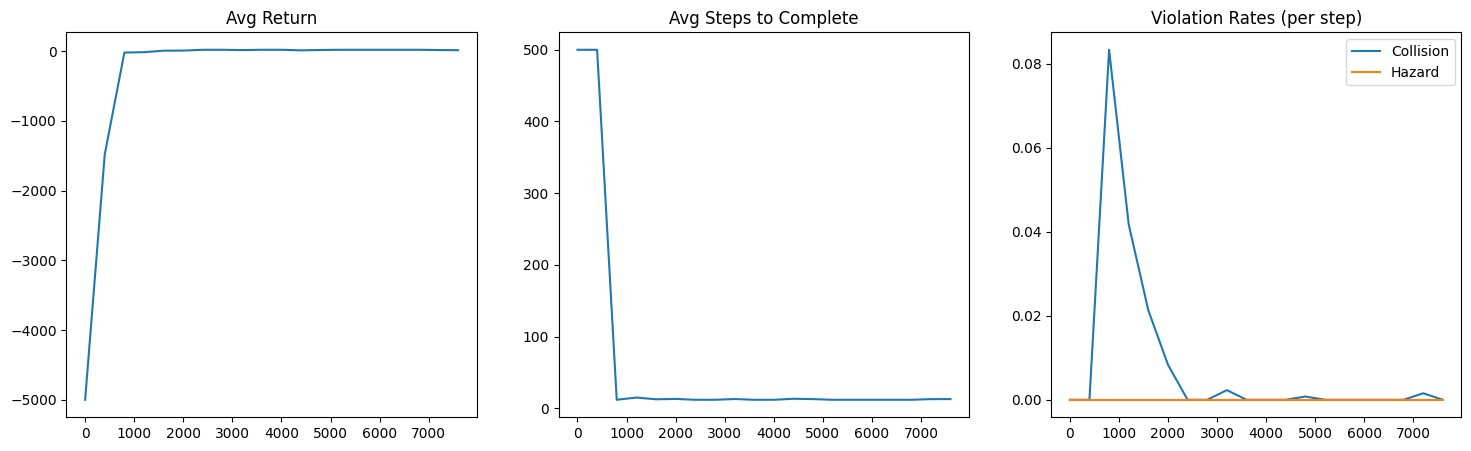

In [9]:
plot_learning_curves(history1)

The plots above show that in Phase 1, the return increases and violation rates drop to zero. The policy visualization below confirms that Agent A learns to avoid the lake when flooded.

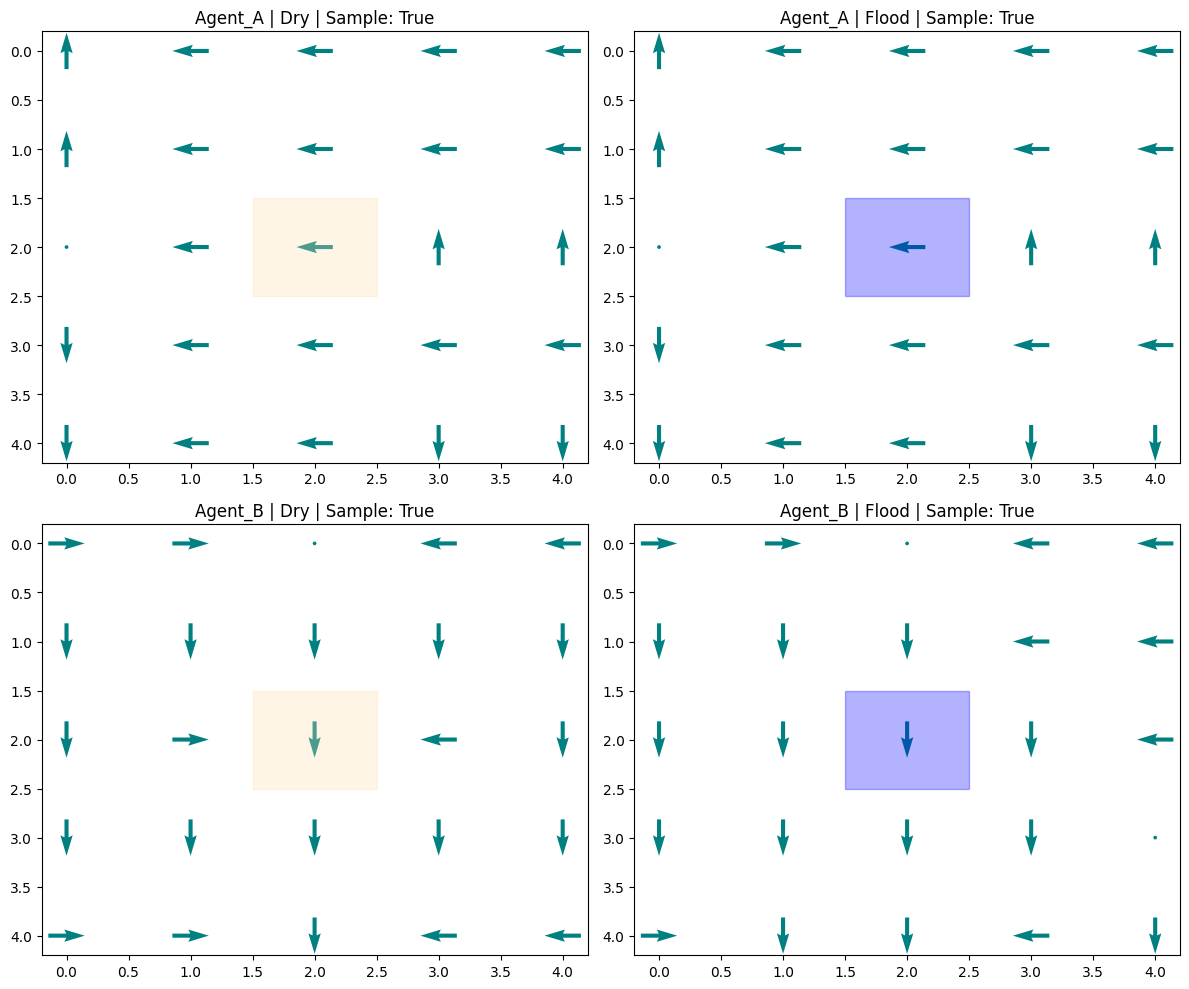

In [10]:
compare_policies(agents1['Agent_A'], agents1['Agent_B'], env1)

Interpretation: The arrows show the preferred action. For Agent A, arrows point away or wait at the lake when flooded. Agent B crosses directly regardless of lake state.

## Task 2: Phase 2 Training
In Phase 2, both agents are waterproofed. The game is now symmetric. We hypothesize that without a correlating mechanism, independent learners will struggle to coordinate at the intersection, leading to persistent collisions.

In [11]:
config2 = ExperimentConfig.from_dict(STAGE2_PHASE2_CONFIG)
env2 = StochasticMultiAgentEnv(config2.env)
agents2 = {"Agent_A": TabularQAgent("Agent_A", config2.agent, config2.env.p_flood), "Agent_B": TabularQAgent("Agent_B", config2.agent, config2.env.p_flood)}
runner2 = SimulationRunner(config2, env2, agents2)
history2 = runner2.run_experiment()

Episode     0 | Return: -4998.10 | Collisions: 0.0000 | Hazards: 0.0000
Episode   400 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1263
Episode   800 | Return:    -3.09 | Collisions: 0.1107 | Hazards: 0.1052
Episode  1200 | Return:    -8.51 | Collisions: 0.1271 | Hazards: 0.1204
Episode  1600 | Return:    -5.81 | Collisions: 0.1218 | Hazards: 0.1071


Episode  2000 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1087
Episode  2400 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1400
Episode  2800 | Return:     0.21 | Collisions: 0.0997 | Hazards: 0.1041
Episode  3200 | Return:    -5.56 | Collisions: 0.1200 | Hazards: 0.1121


Episode  3600 | Return:   -40.00 | Collisions: 0.2500 | Hazards: 0.1300
Episode  4000 | Return:    32.28 | Collisions: 0.0040 | Hazards: 0.0966
Episode  4400 | Return:     5.39 | Collisions: 0.0705 | Hazards: 0.1013
Episode  4800 | Return:    29.80 | Collisions: 0.0088 | Hazards: 0.0990


Episode  5200 | Return:    25.59 | Collisions: 0.0121 | Hazards: 0.0985
Episode  5600 | Return:    32.33 | Collisions: 0.0051 | Hazards: 0.1112
Episode  6000 | Return:    30.78 | Collisions: 0.0069 | Hazards: 0.0986
Episode  6400 | Return:    28.75 | Collisions: 0.0056 | Hazards: 0.0851
Episode  6800 | Return:    28.28 | Collisions: 0.0018 | Hazards: 0.0908


Episode  7200 | Return:    28.15 | Collisions: 0.0000 | Hazards: 0.0932
Episode  7600 | Return:    26.74 | Collisions: 0.0000 | Hazards: 0.0866
Episode  8000 | Return:    29.06 | Collisions: 0.0078 | Hazards: 0.0975
Episode  8400 | Return:    28.66 | Collisions: 0.0000 | Hazards: 0.0827
Episode  8800 | Return:    27.61 | Collisions: 0.0000 | Hazards: 0.0932
Episode  9200 | Return:    28.15 | Collisions: 0.0000 | Hazards: 0.0898


Episode  9600 | Return:    28.72 | Collisions: 0.0000 | Hazards: 0.0888
Episode 10000 | Return:    29.26 | Collisions: 0.0000 | Hazards: 0.0940
Episode 10400 | Return:    27.73 | Collisions: 0.0000 | Hazards: 0.0935
Episode 10800 | Return:    28.15 | Collisions: 0.0000 | Hazards: 0.0840
Episode 11200 | Return:    29.65 | Collisions: 0.0000 | Hazards: 0.1021
Episode 11600 | Return:    27.33 | Collisions: 0.0063 | Hazards: 0.0923


Episode 12000 | Return:    29.91 | Collisions: 0.0100 | Hazards: 0.0997
Episode 12400 | Return:    31.11 | Collisions: 0.0070 | Hazards: 0.1037
Episode 12800 | Return:    28.78 | Collisions: 0.0000 | Hazards: 0.0847
Episode 13200 | Return:    28.15 | Collisions: 0.0000 | Hazards: 0.0989
Episode 13600 | Return:    29.08 | Collisions: 0.0057 | Hazards: 0.1029
Episode 14000 | Return:    27.70 | Collisions: 0.0000 | Hazards: 0.0933


Episode 14400 | Return:    27.18 | Collisions: 0.0094 | Hazards: 0.1023
Episode 14800 | Return:    26.95 | Collisions: 0.0000 | Hazards: 0.0833


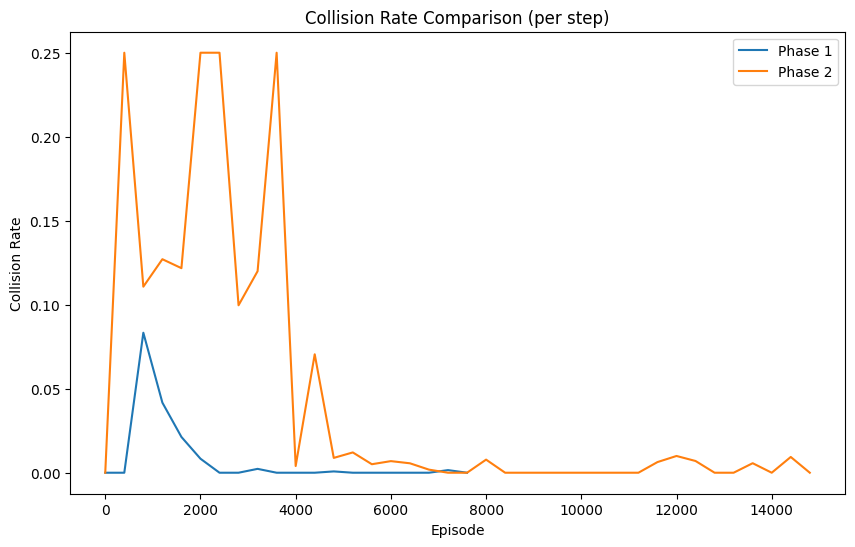

In [12]:
plt.figure(figsize=(10,6)); plt.plot(history1['episodes'], history1['collision_rate'], label='Phase 1'); plt.plot(history2['episodes'], history2['collision_rate'], label='Phase 2')
plt.title("Collision Rate Comparison (per step)"); plt.xlabel("Episode"); plt.ylabel("Collision Rate"); plt.legend(); plt.show()

Interpretation: Phase 2 collision rates remain higher than Phase 1. This confirms that symmetry and non-stationarity prevent independent learners from reaching the coordination equilibrium.

## HD Experiment: Step Cost Magnitude
We investigate how the step penalty affects coordination failure in Phase 2.

Episode     0 | Return: -1000.00 | Collisions: 0.0000 | Hazards: 0.0000


Episode     0 | Return: -3000.00 | Collisions: 0.0000 | Hazards: 0.0000


Episode     0 | Return: -5000.00 | Collisions: 0.0000 | Hazards: 0.0000


Episode     0 | Return: -10000.00 | Collisions: 0.0000 | Hazards: 0.0000


Episode     0 | Return: -20000.00 | Collisions: 0.0000 | Hazards: 0.0000


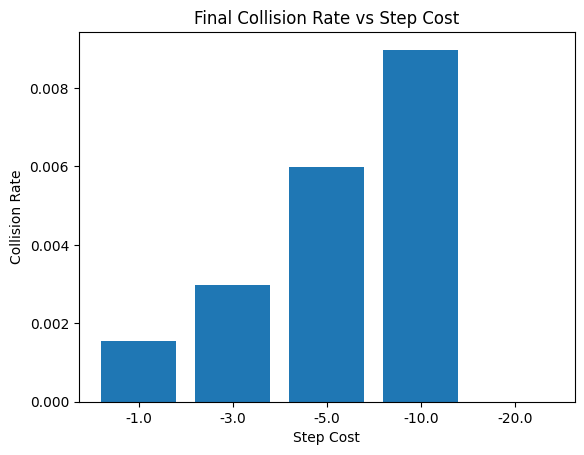

In [13]:
step_costs = [-1.0, -3.0, -5.0, -10.0, -20.0]; final_collisions = []
for cost in step_costs:
    c = STAGE2_PHASE2_CONFIG.copy(); c['env'] = STAGE2_PHASE2_CONFIG['env'].copy(); c['env']['step_cost'] = cost; c['training_episode_budget'] = 5000
    conf = ExperimentConfig.from_dict(c); e = StochasticMultiAgentEnv(conf.env); ags = {"Agent_A": TabularQAgent("Agent_A", conf.agent, conf.env.p_flood), "Agent_B": TabularQAgent("Agent_B", conf.agent, conf.env.p_flood)}
    SimulationRunner(conf, e, ags).run_experiment(eval_interval=5000)
    final_collisions.append(evaluate_greedy(e, ags, episodes=100)['collision_rate'])
plt.bar([str(c) for c in step_costs], final_collisions); plt.title("Final Collision Rate vs Step Cost"); plt.xlabel("Step Cost"); plt.ylabel("Collision Rate"); plt.show()

## Task 3: Game Theory and Replicator Dynamics

### Phase 1: Asymmetric Game
Payoff matrix for A (Expected water hazard at p=0.5):
| | B Cross | B Wait |
|--|--|--|
| A Cross | -25 | -15 |
| A Wait | -3 | -3 |
A has a dominant strategy to **Wait** (-3 > -15).

### Phase 2: Symmetric Game (Anti-coordination)
Payoff for both:
| | Cross | Wait |
|--|--|--|
| Cross | -25 | -5 |
| Wait | -3 | -3 |
This is a Hawk-Dove game with two pure Nash Equilibria: (C,W) and (W,C).

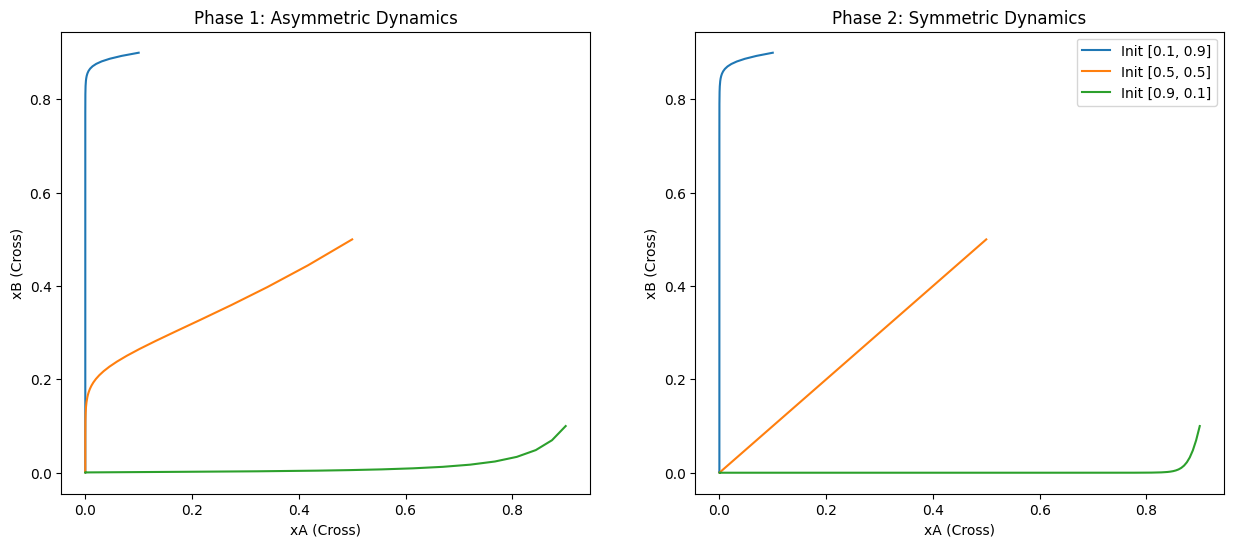

In [14]:
def replicator_phase1(state, t, p_flood=0.5):
    xA, xB = state
    fAC = xB * (-25) + (1-xB) * (p_flood*(-25) + (1-p_flood)*(-5))
    fAW = -3; phiA = xA * fAC + (1-xA) * fAW; dxA = xA * (fAC - phiA)
    fBC = xA * (-25) + (1-xA) * (-5)
    fBW = -3; phiB = xB * fBC + (1-xB) * fBW; dxB = xB * (fBC - phiB)
    return [dxA, dxB]

def replicator_phase2(state, t):
    xA, xB = state
    fAC = xB * (-25) + (1-xB) * (-5); fAW = -3; phiA = xA * fAC + (1-xA) * fAW; dxA = xA * (fAC - phiA)
    fBC = xA * (-25) + (1-xA) * (-5); fBW = -3; phiB = xB * fBC + (1-xB) * fBW; dxB = xB * (fBC - phiB)
    return [dxA, dxB]

t = np.linspace(0, 20, 1000)
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
for x0 in [[0.1, 0.9], [0.5, 0.5], [0.9, 0.1]]:
    sol1 = odeint(replicator_phase1, x0, t); axs[0].plot(sol1[:,0], sol1[:,1], label=f"Init {x0}")
    sol2 = odeint(replicator_phase2, x0, t); axs[1].plot(sol2[:,0], sol2[:,1], label=f"Init {x0}")
axs[0].set_title("Phase 1: Asymmetric Dynamics"); axs[0].set_xlabel("xA (Cross)"); axs[0].set_ylabel("xB (Cross)")
axs[1].set_title("Phase 2: Symmetric Dynamics"); axs[1].set_xlabel("xA (Cross)"); axs[1].set_ylabel("xB (Cross)")
plt.legend(); plt.show()

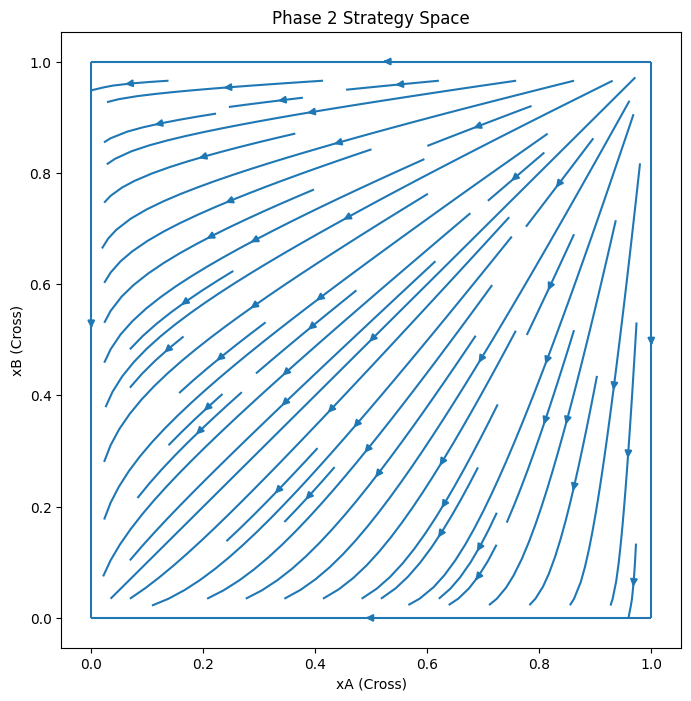

In [15]:
xA, xB = np.meshgrid(np.linspace(0, 1, 20), np.linspace(0, 1, 20))
u = np.zeros_like(xA); v = np.zeros_like(xB)
for i in range(20): 
    for j in range(20):
        d = replicator_phase2([xA[i,j], xB[i,j]], 0); u[i,j], v[i,j] = d[0], d[1]
plt.figure(figsize=(8,8)); plt.streamplot(xA, xB, u, v); plt.title("Phase 2 Strategy Space"); plt.xlabel("xA (Cross)"); plt.ylabel("xB (Cross)"); plt.show()

## Task 4: Theoretical Justification

> **Phase 1** presents an **asymmetric game** where Agent A's water hazard creates a dominant strategy: A always prefers to Wait (expected cost −3) over Cross (expected cost −15 at p=0.5), regardless of B's action. This dominant strategy eliminates the coordination problem entirely — it is a **unique Nash Equilibrium** (A=Wait, B=Cross). For Q-learning, this translates to a stationary learning target for each agent: A's environment becomes effectively independent of B once A's optimal policy is fixed, satisfying the stationarity assumption that tabular Q-convergence requires. Phase 1 is solvable by independent learners.
>
> **Phase 2** is an **anti-coordination game** with two pure Nash Equilibria and one unstable mixed equilibrium. Independent Q-learners face **non-stationarity**: each agent's best response shifts as the other adapts, creating oscillating learning targets. The lake's binary state could serve as a **correlating device** (traffic light), but selecting which agent crosses in which state requires **correlated equilibrium** selection — a mechanism absent from independent Q-learning. This is precisely why Robert is wrong and Sarah is right.

## Conclusion
The simulation confirms Sarah's theory: while asymmetry in Phase 1 facilitates coordination through a unique Nash Equilibrium, the symmetry of Phase 2 leads to coordination failure in independent reinforcement learners. The results demonstrate the critical role of correlated equilibria and stationary targets in multi-agent systems.